In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df=pd.read_csv('CarPrice_Assignment.csv')

In [2]:
print(df.head)

<bound method NDFrame.head of      car_ID  symboling                   CarName fueltype aspiration  \
0         1          3        alfa-romero giulia      gas        std   
1         2          3       alfa-romero stelvio      gas        std   
2         3          1  alfa-romero Quadrifoglio      gas        std   
3         4          2               audi 100 ls      gas        std   
4         5          2                audi 100ls      gas        std   
..      ...        ...                       ...      ...        ...   
200     201         -1           volvo 145e (sw)      gas        std   
201     202         -1               volvo 144ea      gas      turbo   
202     203         -1               volvo 244dl      gas        std   
203     204         -1                 volvo 246   diesel      turbo   
204     205         -1               volvo 264gl      gas      turbo   

    doornumber      carbody drivewheel enginelocation  wheelbase  ...  \
0          two  convertible     

In [3]:
x=df[['enginesize','horsepower','citympg','highwaympg']]

In [4]:
y=df['price']

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
scaler=StandardScaler()
x_train_scaled =scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [7]:
model=LinearRegression()
model.fit(x_train_scaled,y_train)

LinearRegression()

In [8]:
y_pred=model.predict(x_test_scaled)


In [9]:
print('Name: SAHANA.S')
print('Reg. No: 25004522')
print('MODEL COEFFICENTS:')
for feature,coef in zip(x.columns,model.coef_):
    print(f"{feature:>12}:{coef:>10.2f}")
print(f"{'Intercept':>12}:{model.intercept_:>10.2f}")

Name: SAHANA.S
Reg. No: 25004522
MODEL COEFFICENTS:
  enginesize:   4523.40
  horsepower:   1694.22
     citympg:   -392.57
  highwaympg:   -816.36
   Intercept:  13223.41


In [10]:
print('\nMODEL PERFORMANCE:')
print(f"{'MSE':>12}:{mean_squared_error(y_test,y_pred):>10.2f}")
print(f"{'RMSE':>12}:{np.sqrt(mean_squared_error(y_test,y_pred)):10.2f}")


MODEL PERFORMANCE:
         MSE:16471505.90
        RMSE:   4058.51


In [11]:
print(f'R-squared: {r2_score(y_test, y_pred)}')


R-squared: 0.7913520781370976


In [12]:
print(f"{'MAE':>12}:{mean_absolute_error(y_test,y_pred):>10.2f}")


         MAE:   2892.63


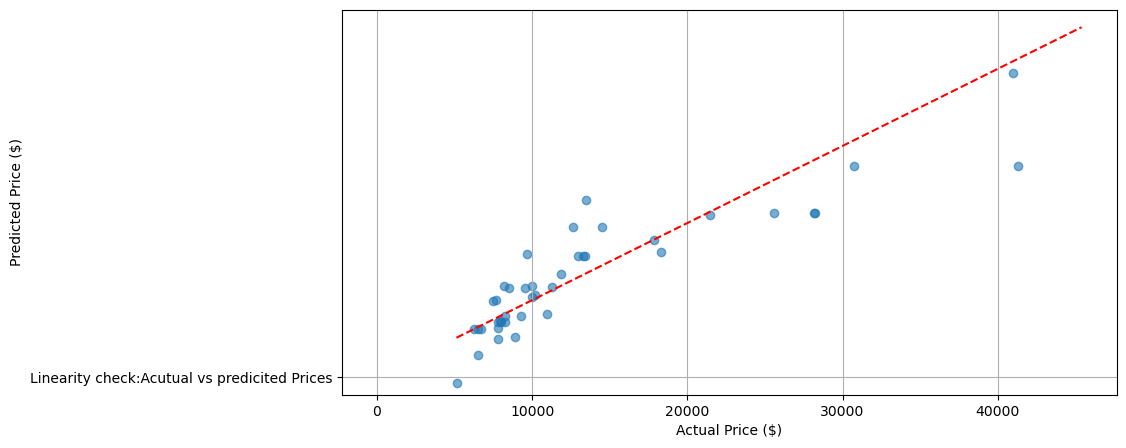

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.plot("Linearity check:Acutual vs predicited Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.grid(True)
plt.show()

In [16]:
residuals=y_test - y_pred
dw_test=sm.stats.durbin_watson(residuals)
print(f"\nDurbin-Watson Statistics:{dw_test:.2f}",
      "\n(Values close to 2 indicate no autocorrelation)")


Durbin-Watson Statistics:2.28 
(Values close to 2 indicate no autocorrelation)


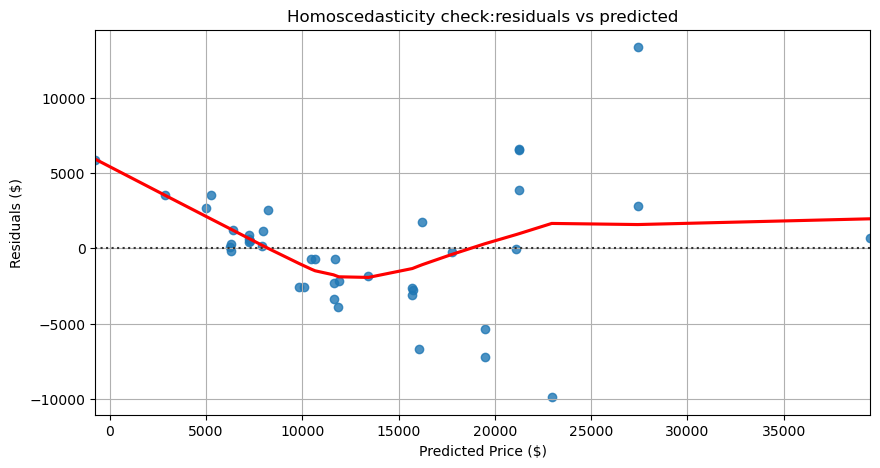

In [19]:
plt.figure(figsize=(10,5))
sns.residplot(x=y_pred,y=residuals,lowess=True,line_kws={'color':'red'})
plt.title("Homoscedasticity check:residuals vs predicted")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Q-Q Plot')

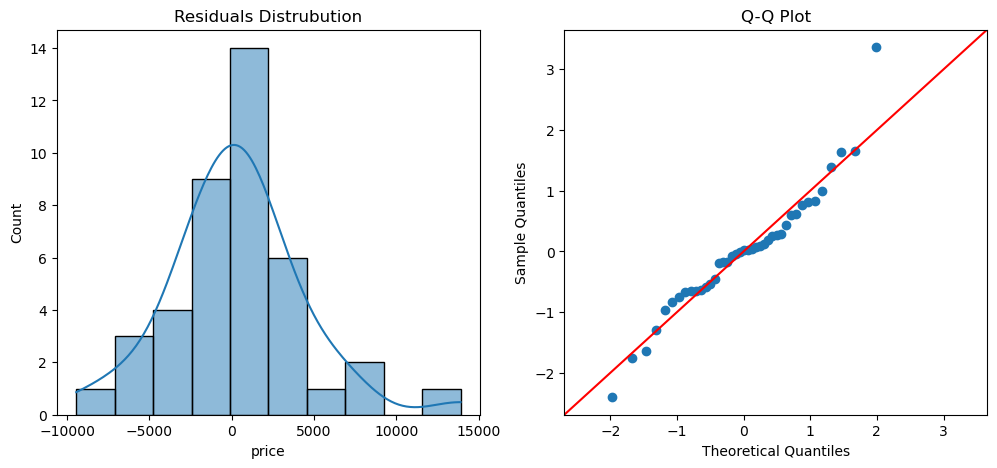

In [21]:
fig, (ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
sns.histplot(residuals,kde=True,ax=ax1)
ax1.set_title("Residuals Distrubution")
sm.qqplot(residuals,line='45',fit=True,ax=ax2)
ax2.set_title("Q-Q Plot")